In [31]:
import numpy as np
import matplotlib.pyplot as plt
import time 
import random
import math

Size (N)   | Naive Time      | NumPy Time     
--------------------------------------------------
3x3       | 0.000023 s | 0.000031 s
6x6       | 0.000057 s | 0.000016 s
12x12      | 0.000343 s | 0.000018 s
24x24      | 0.002496 s | 0.000044 s
48x48      | 0.020713 s | 0.000057 s
96x96      | 0.146804 s | 0.003837 s
192x192     | 1.277258 s | 0.001074 s
384x384     | 11.254532 s | 0.004624 s


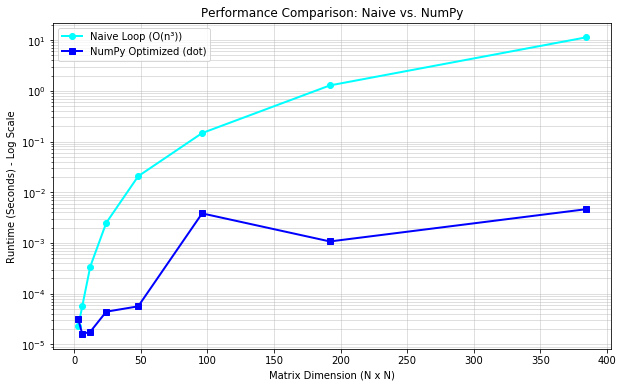

In [55]:
a = np.random.rand(3, 3)
a2 = np.random.rand(3, 3)

b = np.random.rand(6, 6)
b2 = np.random.rand(6, 6)

c = np.random.rand(12, 12)
c2= np.random.rand(12, 12)

d = np.random.rand(24, 24)
d2 = np.random.rand(24, 24)

e = np.random.rand(48, 48)
e2 = np.random.rand(48, 48)

f = np.random.rand(96, 96)
f2 = np.random.rand(96, 96)

g = np.random.rand(192, 192)
g2 = np.random.rand(192, 192)

h = np.random.rand(384, 384)
h2 = np.random.rand(384, 384)

def naive_matrix_multiplication(A, B):
    n = len(A)
    C = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]
    return C

sizes = [3, 6, 12, 24, 48, 96, 192, 384]


naive_durations = [] #store plots
numpy_durations = []

print(f"{'Size (N)':<10} | {'Naive Time':<15} | {'NumPy Time' :<15}")
print("-" * 50)

for n in sizes:
    # Generate data
    A_list = np.random.rand(n, n).tolist()
    B_list = np.random.rand(n, n).tolist()
    
    # Time with naive matrix multiplier
    time_start = time.perf_counter()
    _ = naive_matrix_multiplication(A_list, B_list)
    duration = time.perf_counter() - time_start
    naive_durations.append(duration) # --- Store it ---
    
    # Time with numpy multiplier 
    A_np = np.array(A_list)
    B_np = np.array(B_list)
    start = time.perf_counter()
    _ = np.dot(A_np, B_np) 
    time_numpy = time.perf_counter() - start
    numpy_durations.append(time_numpy) # --- Store it ---

    print(f"{n}x{n:<7} | {duration:.6f} s | {time_numpy:.6f} s")

# plotting lists 
plt.figure(figsize=(10, 6))

plt.plot(sizes, naive_durations, 'o-', label='Naive Loop (O(n³))', color='cyan', linewidth=2)
plt.plot(sizes, numpy_durations, 's-', label='NumPy Optimized (dot)', color='blue', linewidth=2)

plt.yscale('log')
plt.xlabel('Matrix Dimension (N x N)')
plt.ylabel('Runtime (Seconds) - Log Scale')
plt.title('Performance Comparison: Naive vs. NumPy')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()